# **1. Loading Dataset**
menggunakan dataset 1: apples and oranges

In [2]:
#menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
import pandas as pd

# membaca file csv menggunakan pandas
df = pd.read_csv("/content/gdrive/MyDrive/Machine Learning/Pertemuan7 (MenjelangUTS)/Praktikum/data/apples_and_oranges.csv")

# cetak header data (5 baris data) dari file
df.head()

,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange


Menampilkan informasi detail dengan df.info()

In [5]:
# Menampilkan informasi detail
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  40 non-null     int64  
 1   Size    40 non-null     float64
 2   Class   40 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB


Menampilkan statistika deskriptif dari dataset

In [6]:
# Menampilkan statistika deskriptif dari dataset
df.describe()

,Weight,Size
count,40.000000,40.000000
mean,70.200000,4.922750
std,3.039906,0.590063
min,65.000000,4.010000
25%,68.000000,4.360000
50%,70.000000,4.930000
75%,73.000000,5.472500
max,75.000000,5.850000


Cek nilai pada kolom Class

In [7]:
# Cek nilai pada kolom Species
df['Class'].unique()

array(['orange', 'apple'], dtype=object)

Menghitung jumlah pada kolom Class

In [8]:
# Menghitung jumlah pada kolom Species
df['Class'].value_counts()

,count
Class,
orange,20
apple,20


In [9]:
X = df[['Weight', 'Size']]

# Kolom terget (label)
y = df['Class']

In [13]:
X.head()

,Weight,Size
0,69,4.39
1,69,4.21
2,65,4.09
3,72,5.85
4,67,4.70


In [12]:
y.head()

,Class
0,orange
1,orange
2,orange
3,apple
4,orange


# **2. Pemilihan Fitur**
Pemisahan antara fitur (X) dan label (y)

In [14]:
X = df[['Weight', 'Size']]

# Kolom terget (label)
y = df['Class']

In [15]:
X.head()

,Weight,Size
0,69,4.39
1,69,4.21
2,65,4.09
3,72,5.85
4,67,4.70


In [16]:
y.head()

,Class
0,orange
1,orange
2,orange
3,apple
4,orange


# **3. Split dan Bangun Model SVM**
Dataset dibagi menjadi data training (80%) dan data testing (20%) menggunakan fungsi
train_test_split(). Data training digunakan untuk melatih model, sedangkan data testing digunakan
untuk menguji performa model.


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Membuat model SVM dengan karnel linear
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

# **4. Evaluasi Akurasi dan Report Klasifikasi**
Mengevaluasi performa model SVM yang telah dilatih. Proses dilakukan dengan
memprediksi data uji menggunakan perintah model.predict(X_test) dan menyimpan hasilnya ke variabel
y_pred.

In [18]:
y_pred = model.predict(X_test)
# Akurasi
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")
# Laporan klasifikasi
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi: 100.00%

Laporan Klasifikasi:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00         3
      orange       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



# **5. Confusion Matrix**

Menampilkan hasil klasifikasi model dalam bentuk Confusion Matrix, yaitu
tabel yang menunjukkan jumlah prediksi benar dan salah untuk setiap kelas.

Kode confusion_matrix(y_test, y_pred) menghasilkan matriks perbandingan antara label sebenarnya
(True Labels) dan label hasil prediksi (Predicted Labels). Visualisasi dibuat menggunakan
seaborn.heatmap() agar lebih mudah dibaca


Confusion Matrix:
 [[3 0]
 [0 5]]


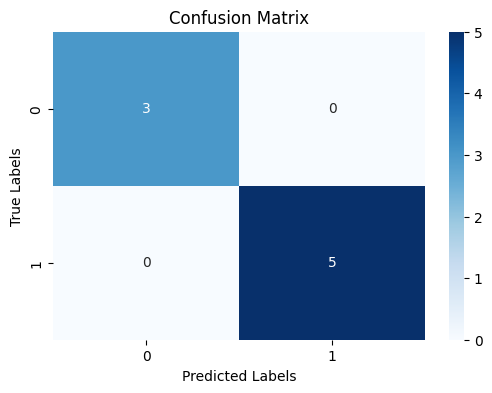

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Jika kamu tau nama kelas (opsional, agar lebih informatif)
# misalnya: class_names = ['Negatif', 'Positif']
# maka tambahkan ke heatmap di bagian "xticklabels" dan "yticklabels"

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# **6. Visualisasi Hasil Model SVM**
Menampilkan visualisasi sebaran data pada dataset Iris berdasarkan dua fitur
utama yaitu Sepal Length dan Sepal Width. Visualisasi dibuat menggunakan fungsi plt.scatter() dari
library Matplotlib, dengan warna titik (c) merepresentasikan masing-masing.

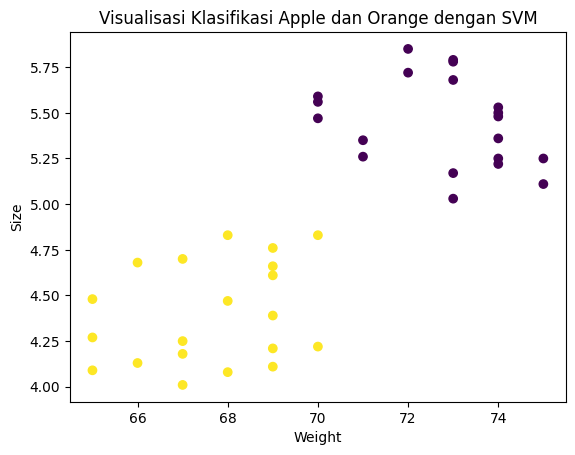

In [24]:
import matplotlib.pyplot as plt

plt.scatter(df['Weight'], df['Size'], c=df['Class'].astype('category').cat.codes)
plt.xlabel('Weight')
plt.ylabel('Size')
plt.title('Visualisasi Klasifikasi Apple dan Orange dengan SVM')
plt.show()


# **7. 3D Visualisasi Hasil Model SVM**
Menampilkan hasil klasifikasi dataset Iris dalam bentuk grafik tiga dimensi (3D)
agar pola antar kelas terlihat lebih jelas

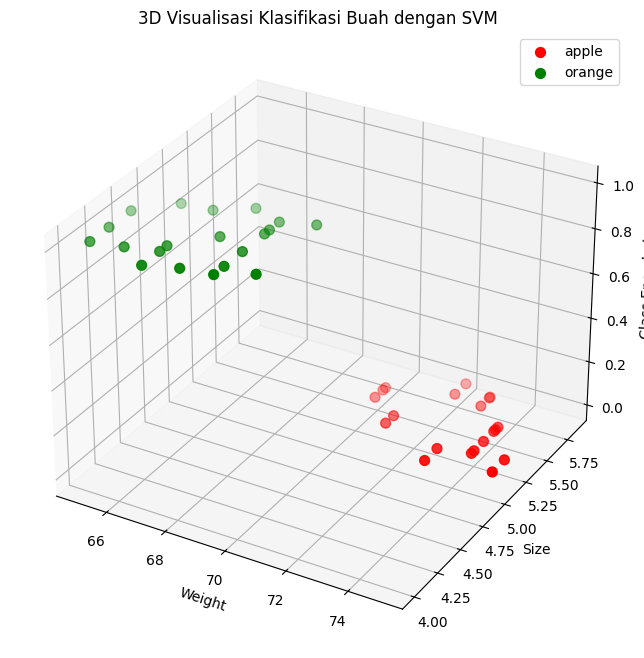

In [23]:
# 3D Visualisasi Hasil Model SVM

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Encode label (ubah teks jadi angka)
le = LabelEncoder()
df['ClassEncoded'] = le.fit_transform(df['Class'])

# Plot 3D hasil klasifikasi
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Warna untuk tiap kelas
colors = ['r', 'g']
labels = le.classes_

# plot tiap kelas dengan warna berbeda
for i, kelas in enumerate(labels):
    subset = df[df['ClassEncoded'] == i]
    ax.scatter(
        subset['Weight'],
        subset['Size'],
        subset['ClassEncoded'],  # sumbu z diganti ke nilai encoded agar bisa divisualisasikan
        color=colors[i],
        label=kelas,
        s=50
    )

ax.set_xlabel('Weight')
ax.set_ylabel('Size')
ax.set_zlabel('Class Encoded')
ax.set_title('3D Visualisasi Klasifikasi Buah dengan SVM')
ax.legend()
plt.show()